# Testes de Hipóteses e Inferência Estatística

Nos capítulos anteriores, descrevemos os dados e estudamos distribuições de probabilidade. Agora avançamos para a **inferência estatística**: usar uma amostra para avaliar afirmações sobre uma população e quantificar a incerteza envolvida.

Em ciência de dados, esse raciocínio aparece em testes A/B, comparação de modelos, campanhas de marketing e experimentos de produto. Perguntas como “a nova versão converte mais?” ou “o modelo A supera o modelo B?” exigem mais do que comparar médias observadas.

A sequência básica é:

1. definir a pergunta e as hipóteses;
2. escolher uma estatística e um teste adequado;
3. quantificar a incerteza com intervalos de confiança e/ou p-valores;
4. decidir se há evidência suficiente contra a hipótese nula;
5. interpretar o resultado no contexto do problema.

Este notebook começa pelos **intervalos de confiança**, introduz formalmente os **testes de hipótese** e termina com aplicações em comparação de modelos e seleção de atributos.

In [41]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from scipy.stats import norm, t

sns.set_theme(style='whitegrid')

## Intervalos de confiança

Um **intervalo de confiança (IC)** fornece uma faixa de valores plausíveis para um parâmetro populacional a partir de uma amostra. Ele complementa a estimativa pontual mostrando sua incerteza.

Para a média, quando o desvio padrão populacional $\sigma$ é conhecido, o intervalo baseado na normal é

$$
IC = \bar{x} \pm z_{1-\alpha/2}\frac{\sigma}{\sqrt{n}}.
$$

Aqui, $\bar{x}$ é a média amostral, $n$ é o tamanho da amostra e $z_{1-\alpha/2}$ é o valor crítico da normal padrão.

Na interpretação frequentista, um procedimento de IC de 95% produziria intervalos que contêm o verdadeiro parâmetro em aproximadamente 95% de muitas repetições do experimento. O nível de confiança maior produz, em geral, um intervalo mais largo.

n = 100
Média = 159.25
σ = 13.65
IC-z de 95% = (156.57, 161.93)
Margem de erro = 2.68


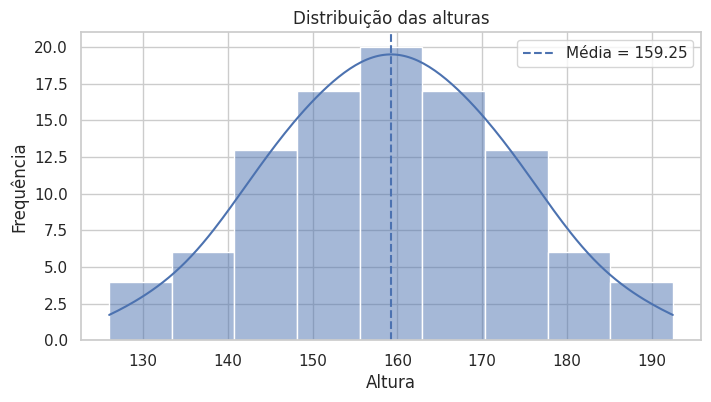

In [42]:
# Dados usados no exemplo original do notebook
dados_altura = np.array([
    126., 129.5, 133., 133., 136.5, 136.5, 140., 140., 140., 140.,
    143.5, 143.5, 143.5, 143.5, 143.5, 143.5, 147., 147., 147., 147.,
    147., 147., 147., 150.5, 150.5, 150.5, 150.5, 150.5, 150.5, 150.5,
    150.5, 154., 154., 154., 154., 154., 154., 154., 154., 154., 157.5,
    157.5, 157.5, 157.5, 157.5, 157.5, 157.5, 157.5, 157.5, 157.5, 161.,
    161., 161., 161., 161., 161., 161., 161., 161., 161., 164.5, 164.5,
    164.5, 164.5, 164.5, 164.5, 164.5, 164.5, 164.5, 168., 168., 168.,
    168., 168., 168., 168., 168., 171.5, 171.5, 171.5, 171.5, 171.5,
    171.5, 171.5, 175., 175., 175., 175., 175., 175., 178.5, 178.5,
    178.5, 178.5, 182., 182., 185.5, 185.5, 189., 192.5
])

n = len(dados_altura)
media = dados_altura.mean()

# Apenas para ilustrar o IC-z, tratamos este valor como sigma conhecido.
sigma = dados_altura.std(ddof=0)
alpha = 0.05
z_critico = norm.ppf(1 - alpha / 2)
margem = z_critico * sigma / np.sqrt(n)
ic_z = (media - margem, media + margem)

print(f'n = {n}')
print(f'Média = {media:.2f}')
print(f'σ = {sigma:.2f}')
print(f'IC-z de 95% = ({ic_z[0]:.2f}, {ic_z[1]:.2f})')
print(f'Margem de erro = {margem:.2f}')

# Visualização da distribuição usada no exemplo
plt.figure(figsize=(8, 4))
sns.histplot(dados_altura, kde=True)
plt.axvline(media, linestyle='--', label=f'Média = {media:.2f}')
plt.title('Distribuição das alturas')
plt.xlabel('Altura')
plt.ylabel('Frequência')
plt.legend()
plt.show()


In [43]:
for nivel in [0.80, 0.90, 0.95, 0.99]:
    alpha_nivel = 1 - nivel
    z = norm.ppf(1 - alpha_nivel / 2)
    margem = z * sigma / np.sqrt(n)
    print(
        f'{nivel:.0%}: ({media - margem:.2f}, {media + margem:.2f}) '
        f'| margem = {margem:.2f}'
    )

80%: (157.50, 161.00) | margem = 1.75
90%: (157.00, 161.50) | margem = 2.25
95%: (156.57, 161.93) | margem = 2.68
99%: (155.73, 162.77) | margem = 3.52


Quando $\sigma$ é **desconhecido**, substituímos o desvio populacional pelo desvio padrão amostral $s$ e usamos a distribuição t de Student:

$$
IC = \bar{x} \pm t_{1-\alpha/2,\,n-1}\frac{s}{\sqrt{n}}.
$$

A distribuição t é especialmente importante em amostras pequenas, mas seu uso não depende de uma regra rígida como $n<30$: o ponto central é que $\sigma$ é desconhecido. Conforme os graus de liberdade aumentam, a t se aproxima da normal.

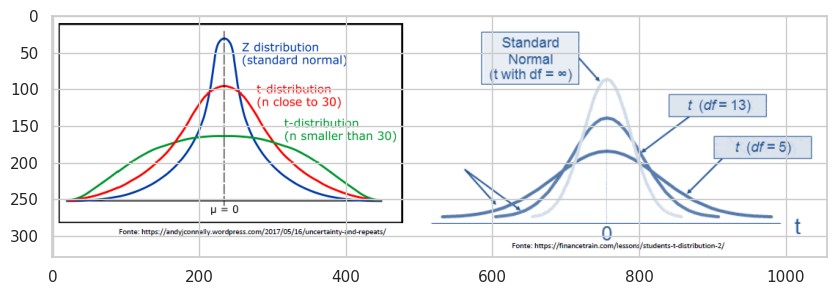

In [44]:
# incuir figura png do diretorio
import matplotlib.image as mpimg
img = mpimg.imread('../_static/t-student.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)

In [45]:
dados_t = np.array([149., 160., 147., 189., 175., 168., 156., 160., 152.])

n_t = len(dados_t)
media_t = dados_t.mean()
s_t = dados_t.std(ddof=1)
se_t = s_t / np.sqrt(n_t)
ic_t = t.interval(0.95, df=n_t - 1, loc=media_t, scale=se_t)

print(f'n = {n_t}')
print(f'Média = {media_t:.2f}')
print(f's = {s_t:.2f}')
print(f'IC-t de 95% = ({ic_t[0]:.2f}, {ic_t[1]:.2f})')

n = 9
Média = 161.78
s = 13.56
IC-t de 95% = (151.35, 172.20)


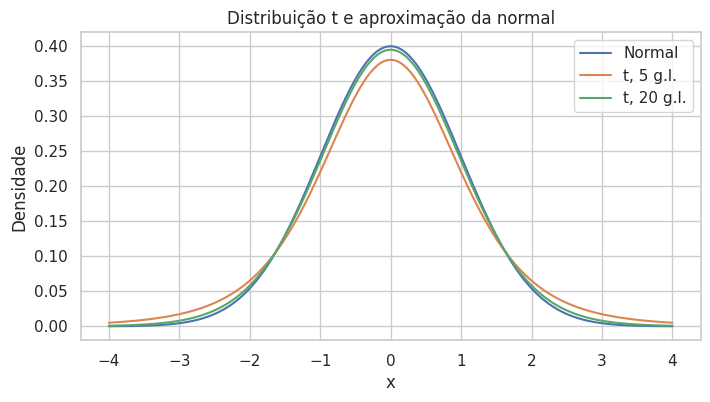

In [46]:
x = np.linspace(-4, 4, 1000)
plt.figure(figsize=(8, 4))
plt.plot(x, norm.pdf(x), label='Normal')
plt.plot(x, t.pdf(x, df=5), label='t, 5 g.l.')
plt.plot(x, t.pdf(x, df=20), label='t, 20 g.l.')
plt.title('Distribuição t e aproximação da normal')
plt.xlabel('x')
plt.ylabel('Densidade')
plt.legend()
plt.show()

## Testes de hipótese

Um teste de hipótese transforma uma pergunta em duas afirmações concorrentes:

- **Hipótese nula ($H_0$):** representa a ausência do efeito ou diferença que queremos detectar.
- **Hipótese alternativa ($H_1$):** representa o efeito ou diferença de interesse.

Escolhemos antes do teste um **nível de significância** $\alpha$, frequentemente 0,05. Ele controla a probabilidade máxima de **erro tipo I** no procedimento: rejeitar $H_0$ quando ela é verdadeira.

O **p-valor** é a probabilidade, assumindo $H_0$ verdadeira, de obter uma estatística de teste tão extrema quanto ou mais extrema que a observada. A regra usual é:

- se $p < \alpha$, rejeitamos $H_0$;
- se $p \geq \alpha$, **não rejeitamos $H_0$**.

Não rejeitar $H_0$ não significa provar que ela é verdadeira. Também existe o **erro tipo II**, que ocorre quando não rejeitamos $H_0$ mesmo havendo um efeito real.

O teste deve ser escolhido de acordo com o tipo de variável, o desenho do experimento e os pressupostos envolvidos.

### Testes z, t e qui-quadrado

O **teste z** é usado em problemas de média quando a variabilidade populacional é conhecida ou quando uma aproximação normal está bem justificada. Para uma amostra com média $\bar{x}$, sob $H_0:\mu=\mu_0$,

$$
Z = \frac{\bar{x}-\mu_0}{\sigma/\sqrt{n}}.
$$

No exemplo abaixo, usamos a média e o desvio do conjunto original como referência e verificamos se uma nova amostra simulada apresenta média maior.

In [47]:
dados_originais = dados_altura.copy()
mu0 = dados_originais.mean()
sigma0 = dados_originais.std(ddof=0)

# Nova amostra simulada com aumento de 3%
dados_novos = dados_originais * 1.03
media_nova = dados_novos.mean()
n_novo = len(dados_novos)

z_stat = (media_nova - mu0) / (sigma0 / np.sqrt(n_novo))
p_value_z = norm.sf(z_stat)  # teste unilateral: H1: mu > mu0

print(f'H0: μ = {mu0:.2f}')
print(f'H1: μ > {mu0:.2f}')
print(f'Z = {z_stat:.3f}')
print(f'p-valor = {p_value_z:.6f}')

H0: μ = 159.25
H1: μ > 159.25
Z = 3.500
p-valor = 0.000233


In [48]:
alpha = 0.05

if p_value_z < alpha:
    print('Rejeitamos H0: há evidência de aumento da média.')
else:
    print('Não rejeitamos H0: a evidência de aumento é insuficiente.')

Rejeitamos H0: há evidência de aumento da média.


Quando $\sigma$ é desconhecido, o **teste t** é a alternativa natural para médias. Se as observações antes e depois correspondem aos mesmos indivíduos ou unidades, usamos o **teste t pareado**, que testa a média das diferenças entre os pares.

In [49]:
from scipy.stats import ttest_rel

dados_t_originais = np.array([149., 160., 147., 189., 175., 168., 156., 160., 152.])
dados_t_novos = dados_t_originais * 1.02

t_stat, p_value_t = ttest_rel(dados_t_originais, dados_t_novos)

print(f't = {t_stat:.3f}')
print(f'p-valor bicaudal = {p_value_t:.6f}')

alpha = 0.05
if p_value_t < alpha:
    print('Rejeitamos H0: a média das diferenças é diferente de zero.')
else:
    print('Não rejeitamos H0.')

t = -35.785
p-valor bicaudal = 0.000000
Rejeitamos H0: a média das diferenças é diferente de zero.


O **teste qui-quadrado de independência** trabalha com frequências em uma tabela de contingência. Ele avalia se duas variáveis categóricas estão associadas.

- $H_0$: as variáveis são independentes;
- $H_1$: existe associação entre elas.

In [50]:
from scipy.stats import chi2_contingency

tabela = np.array([[30, 20],
                   [22, 28]])

chi2_stat, p_value_chi2, gl, esperadas = chi2_contingency(tabela)

print(f'χ² = {chi2_stat:.3f}')
print(f'graus de liberdade = {gl}')
print(f'p-valor = {p_value_chi2:.4f}')
print('Frequências esperadas:')
print(np.round(esperadas, 2))

χ² = 1.963
graus de liberdade = 1
p-valor = 0.1612
Frequências esperadas:
[[26. 24.]
 [26. 24.]]


## Comparação de modelos de classificação

Os mesmos conceitos podem ser usados para estudar o desempenho de algoritmos. O exemplo original compara **Naive Bayes**, **Regressão Logística** e **Random Forest** na base `credit_data.csv`.

Em vez de olhar apenas uma divisão treino/teste, repetimos uma validação cruzada de 10 folds com 30 sementes diferentes. Cada repetição produz uma **acurácia média**, formando uma distribuição de 30 resultados por modelo. Isso permite observar não apenas desempenho médio, mas também variabilidade.

Antes de usar esses algoritmos, precisamos apenas de uma noção do que cada um faz. **O objetivo aqui não é estudar os modelos em profundidade**, mas usá-los como exemplos para aplicar ferramentas estatísticas à comparação de desempenho. Eles serão retomados com mais detalhes nos capítulos de Machine Learning.

- **Naive Bayes:** classificador probabilístico baseado no Teorema de Bayes. A versão usada aqui assume, de forma simplificada, independência condicional entre as variáveis.
- **Regressão Logística:** apesar do nome, é muito utilizada para **classificação**. O modelo estima a probabilidade de uma observação pertencer a determinada classe.
- **Random Forest:** combina várias **árvores de decisão** e agrega suas previsões, reduzindo a dependência de uma única árvore.

Neste ponto, basta guardar a ideia central: **modelos diferentes podem produzir desempenhos diferentes e esses desempenhos variam conforme os dados usados na avaliação**. Essa variabilidade é justamente o que queremos analisar estatisticamente.

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB

credit = pd.read_csv('data/credit_data.csv').dropna()

X_credit = credit.iloc[:, 1:4].values
y_credit = credit.iloc[:, 4].values

# 30 médias: uma média para cada repetição da validação cruzada
resultados = {
    'Naive Bayes': [],
    'Logística': [],
    'Random Forest': []
}

# 300 scores: 30 repetições × 10 folds, preservando a ideia do notebook original
resultados_folds = {
    'Naive Bayes': [],
    'Logística': [],
    'Random Forest': []
}

for i in range(30):
    kfold = KFold(n_splits=10, shuffle=True, random_state=i)

    modelos = {
        'Naive Bayes': GaussianNB(),
        'Logística': LogisticRegression(max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=i)
    }

    for nome, modelo in modelos.items():
        scores = cross_val_score(modelo, X_credit, y_credit, cv=kfold)
        resultados[nome].append(scores.mean())
        resultados_folds[nome].extend(scores)

resultados = {
    nome: np.asarray(valores)
    for nome, valores in resultados.items()
}

resultados_folds = {
    nome: np.asarray(valores)
    for nome, valores in resultados_folds.items()
}

pd.DataFrame({
    nome: {
        'Média': valores.mean(),
        'Desvio padrão': valores.std(ddof=1)
    }
    for nome, valores in resultados.items()
}).T.round(4)


,Média,Desvio padrão
Naive Bayes,0.9249,0.0008
Logística,0.9138,0.0036
Random Forest,0.9869,0.0016


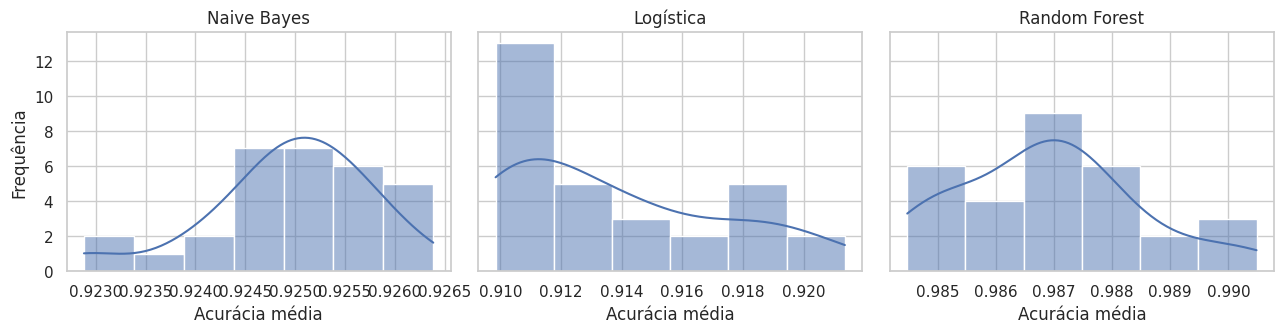

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

for ax, (nome, valores) in zip(axes, resultados.items()):
    sns.histplot(valores, kde=True, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('Acurácia média')

axes[0].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

O gráfico anterior resume as **30 acurácias médias**, uma para cada repetição da validação cruzada. O notebook original também observava os **300 resultados individuais dos folds** ($30 \times 10$). Essa segunda visão mostra com mais detalhe a dispersão das avaliações, embora os folds de uma validação cruzada não devam ser tratados como 300 observações totalmente independentes.

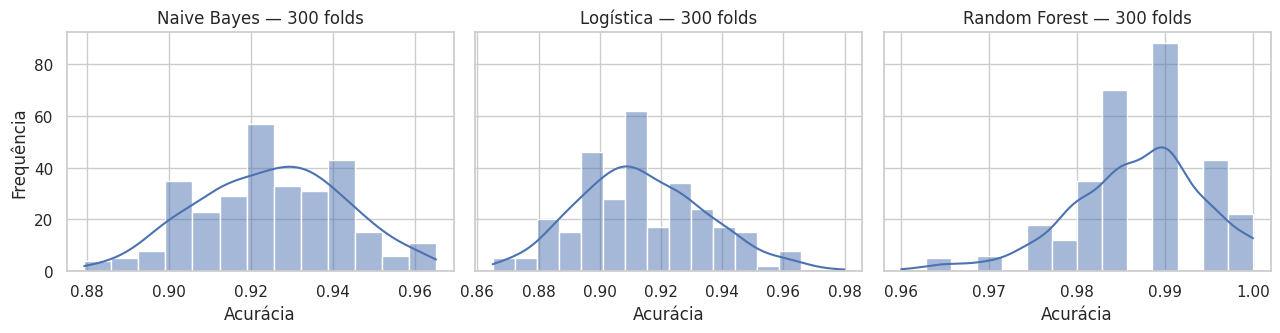

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

for ax, (nome, valores) in zip(axes, resultados_folds.items()):
    sns.histplot(valores, kde=True, ax=ax)
    ax.set_title(f'{nome} — 300 folds')
    ax.set_xlabel('Acurácia')

axes[0].set_ylabel('Frequência')
plt.tight_layout()
plt.show()

Para cada conjunto de 30 médias, podemos calcular um IC-t para a **média das repetições**. O intervalo resume a variabilidade observada nesse experimento; ele não elimina as dependências inerentes à validação cruzada, por isso deve ser interpretado como uma ferramenta didática de comparação, e não como uma garantia absoluta sobre o desempenho futuro.

In [54]:
def intervalo_t(valores, confianca=0.95):
    valores = np.asarray(valores)
    return t.interval(
        confianca,
        df=len(valores) - 1,
        loc=valores.mean(),
        scale=stats.sem(valores)
    )

linhas = []
for nome, valores in resultados.items():
    inferior, superior = intervalo_t(valores)
    linhas.append({
        'Modelo': nome,
        'Acurácia média': valores.mean(),
        'IC 95% inferior': inferior,
        'IC 95% superior': superior
    })

pd.DataFrame(linhas).set_index('Modelo').round(4)

,Acurácia média,IC 95% inferior,IC 95% superior
Modelo,,,
Naive Bayes,0.9249,0.9246,0.9252
Logística,0.9138,0.9124,0.9151
Random Forest,0.9869,0.9863,0.9875


### Normalidade e testes não paramétricos

Antes de escolher um teste paramétrico para comparar resultados, é comum examinar a forma das distribuições. O notebook original usa três testes de normalidade:

- **Shapiro-Wilk:** $H_0$ afirma que os dados são compatíveis com uma distribuição normal;
- **D'Agostino-Pearson:** combina assimetria e curtose;
- **Anderson-Darling:** compara a estatística do teste com valores críticos e dá maior atenção às caudas.

Em todos eles, o objetivo é procurar evidência **contra** a normalidade. Um p-valor alto não prova que a distribuição é normal; apenas indica que o teste não encontrou evidência suficiente para rejeitá-la.

In [55]:
from scipy.stats import anderson, normaltest, shapiro

linhas = []
for nome, valores in resultados.items():
    w_stat, p_shapiro = shapiro(valores)
    k2_stat, p_dagostino = normaltest(valores)

    ad = anderson(valores, dist='norm')
    idx_5 = np.where(np.isclose(ad.significance_level, 5.0))[0][0]
    critico_5 = ad.critical_values[idx_5]

    linhas.append({
        'Modelo': nome,
        'p Shapiro': p_shapiro,
        'p D’Agostino': p_dagostino,
        'AD estatística': ad.statistic,
        'AD crítico 5%': critico_5,
        'AD rejeita normalidade?': ad.statistic > critico_5
    })

pd.DataFrame(linhas).set_index('Modelo').round(4)

,p Shapiro,p D’Agostino,AD estatística,AD crítico 5%,AD rejeita normalidade?
Modelo,,,,,
Naive Bayes,0.0226,0.0499,0.9299,0.712,True
Logística,0.0040,0.1425,1.1808,0.712,True
Random Forest,0.2250,0.5598,0.4498,0.712,False


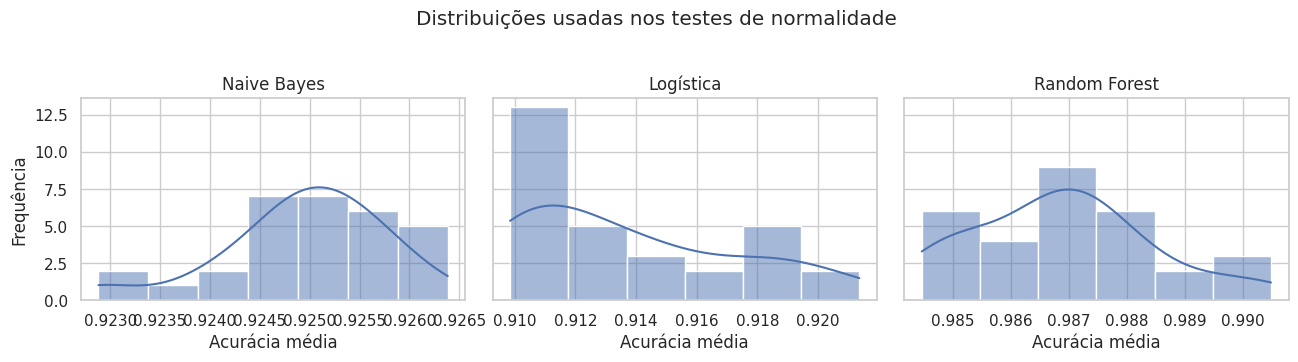

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)

for ax, (nome, valores) in zip(axes, resultados.items()):
    sns.histplot(valores, kde=True, ax=ax)
    ax.set_title(nome)
    ax.set_xlabel('Acurácia média')

axes[0].set_ylabel('Frequência')
fig.suptitle('Distribuições usadas nos testes de normalidade', y=1.03)
plt.tight_layout()
plt.show()

Quando os resultados são **emparelhados** e não queremos depender da normalidade das diferenças, o **Wilcoxon Signed-Rank** é uma alternativa ao teste t pareado. A hipótese nula é que a distribuição das diferenças é centrada em zero.

Para comparar **três ou mais métodos relacionados**, o **teste de Friedman** usa os ranks dos métodos em cada repetição. Ele testa globalmente se há evidência de diferenças sistemáticas entre os desempenhos; se o resultado for significativo, uma análise pós-hoc é necessária para localizar os pares responsáveis pela diferença.

In [57]:
from scipy.stats import friedmanchisquare, wilcoxon

pares = [
    ('Naive Bayes', 'Logística'),
    ('Naive Bayes', 'Random Forest'),
    ('Logística', 'Random Forest')
]

for a, b in pares:
    stat, p = wilcoxon(resultados[a], resultados[b])
    print(f'{a} × {b}: W = {stat:.1f}, p = {p:.6f}')

friedman_stat, friedman_p = friedmanchisquare(
    resultados['Naive Bayes'],
    resultados['Logística'],
    resultados['Random Forest']
)

print()
print(f'Friedman: χ² = {friedman_stat:.3f}, p = {friedman_p:.6f}')

Naive Bayes × Logística: W = 0.0, p = 0.000000
Naive Bayes × Random Forest: W = 0.0, p = 0.000002
Logística × Random Forest: W = 0.0, p = 0.000002

Friedman: χ² = 60.000, p = 0.000000


## ANOVA, Tukey e seleção de atributos

A **ANOVA de uma via** compara as médias de três ou mais grupos independentes em um único teste global.

- $H_0$: todas as médias populacionais são iguais;
- $H_1$: pelo menos uma média difere das demais.

A estatística F compara a variabilidade entre os grupos com a variabilidade dentro dos grupos:

$$
F = \frac{\text{variabilidade entre os grupos}}
         {\text{variabilidade dentro dos grupos}}.
$$

Se a ANOVA rejeita $H_0$, sabemos que existe alguma diferença, mas ainda não sabemos **entre quais grupos**. Um teste post-hoc, como o **Tukey HSD**, realiza essas comparações pareadas controlando o erro associado a múltiplas comparações.

In [58]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import MultiComparison

grupo_a = np.array([165, 152, 143, 140, 155])
grupo_b = np.array([130, 169, 164, 143, 154])
grupo_c = np.array([163, 158, 154, 149, 156])

f_stat, p_anova = f_oneway(grupo_a, grupo_b, grupo_c)
print(f'ANOVA: F = {f_stat:.3f}, p = {p_anova:.4f}')

ANOVA: F = 0.279, p = 0.7614


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     A      B      1.0 0.9891 -17.9023 19.9023  False
     A      C      5.0 0.7648 -13.9023 23.9023  False
     B      C      4.0 0.8411 -14.9023 22.9023  False
-----------------------------------------------------


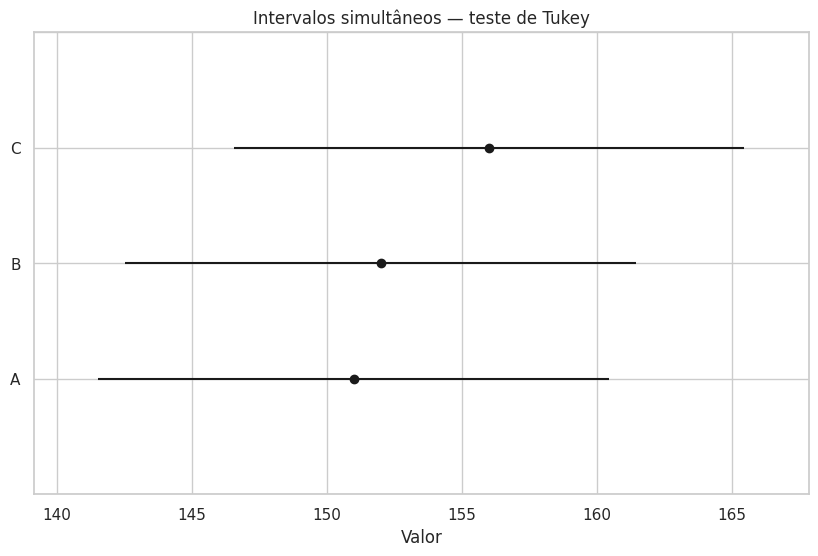

In [59]:
dados_tukey = pd.DataFrame({
    'valor': np.concatenate([grupo_a, grupo_b, grupo_c]),
    'grupo': ['A'] * len(grupo_a) + ['B'] * len(grupo_b) + ['C'] * len(grupo_c)
})

comparacao = MultiComparison(dados_tukey['valor'], dados_tukey['grupo'])
tukey = comparacao.tukeyhsd()
print(tukey)

fig = tukey.plot_simultaneous()
plt.title('Intervalos simultâneos — teste de Tukey')
plt.xlabel('Valor')
plt.show()


Os testes estatísticos também podem atuar como **filtros univariados de atributos**. O `SelectFdr` do scikit-learn calcula um teste para cada variável e seleciona atributos controlando a **False Discovery Rate (FDR)**, isto é, a proporção esperada de falsas descobertas entre as hipóteses rejeitadas.

No exemplo original com `ad.data`, usamos:

- `chi2` para medir associação entre atributos não negativos e a classe;
- `f_classif` para aplicar o teste F da ANOVA a cada atributo.

Esses métodos avaliam cada atributo isoladamente. A acurácia calculada abaixo no próprio conjunto de treino serve apenas para reproduzir o exemplo didático; ela **não deve ser interpretada como desempenho de generalização**.

In [60]:
from sklearn.feature_selection import SelectFdr, chi2, f_classif
from sklearn.metrics import accuracy_score

dataset = pd.read_csv('data/ad.data', header=None)
X = dataset.iloc[:, 0:1558].values
y = dataset.iloc[:, 1558].values

modelo_base = GaussianNB()
modelo_base.fit(X, y)
acc_base = accuracy_score(y, modelo_base.predict(X))

selecao_chi2 = SelectFdr(chi2, alpha=0.01)
X_chi2 = selecao_chi2.fit_transform(X, y)

modelo_chi2 = GaussianNB()
modelo_chi2.fit(X_chi2, y)
acc_chi2 = accuracy_score(y, modelo_chi2.predict(X_chi2))

selecao_anova = SelectFdr(f_classif, alpha=0.01)
X_anova = selecao_anova.fit_transform(X, y)

modelo_anova = GaussianNB()
modelo_anova.fit(X_anova, y)
acc_anova = accuracy_score(y, modelo_anova.predict(X_anova))

pd.DataFrame({
    'Abordagem': ['Sem seleção', 'SelectFdr + χ²', 'SelectFdr + ANOVA'],
    'Nº de atributos': [X.shape[1], X_chi2.shape[1], X_anova.shape[1]],
    'Acurácia no treino': [acc_base, acc_chi2, acc_anova]
}).set_index('Abordagem').round(4)

,Nº de atributos,Acurácia no treino
Abordagem,,
Sem seleção,1558,0.7813
SelectFdr + χ²,433,0.9707
SelectFdr + ANOVA,433,0.9707


O ponto central do capítulo é separar três perguntas diferentes:

- **Qual é a estimativa e sua incerteza?** → intervalo de confiança;
- **Há evidência contra uma hipótese de referência?** → teste de hipótese e p-valor;
- **Qual teste usar?** → depende do tipo de variável, do número de grupos, do pareamento e dos pressupostos do problema.

A significância estatística também não mede, sozinha, a importância prática de um resultado. Em aplicações reais, ela deve ser analisada junto com o **tamanho do efeito**, a incerteza e o contexto da decisão.